In [1]:
!pip install fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 34.8 MB/s eta 0:00:0000:01


In [2]:
import pandas as pd

splits = {'train': 'plain_text/train-00000-of-00001.parquet', 'test': 'plain_text/test-00000-of-00001.parquet', 'unsupervised': 'plain_text/unsupervised-00000-of-00001.parquet'}
df_train = pd.read_parquet("hf://datasets/stanfordnlp/imdb/" + splits["train"], engine="fastparquet")
df_test = pd.read_parquet("hf://datasets/stanfordnlp/imdb/" + splits["test"], engine="fastparquet")
# df_train = pd.read_parquet("Data/Sentiment/" + splits['train'], engine="fastparquet")
# df_test = pd.read_parquet("Data/Sentiment/" + splits['test'], engine="fastparquet")

In [3]:
df_train.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [4]:
df_train.shape, df_test.shape

((25000, 2), (25000, 2))

In [5]:
df_test.head()
df = pd.concat([df_train, df_test], axis=0)
df.shape

(50000, 2)

In [6]:
df[df['label'] == 1].head()

,text,label
12500,Zentropa has much in common with The Third Man...,1
12501,Zentropa is the most original movie I've seen ...,1
12502,Lars Von Trier is never backward in trying out...,1
12503,*Contains spoilers due to me having to describ...,1
12504,That was the first thing that sprang to mind a...,1


In [7]:
import re

def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    return text.split()

tokenize(r"hello what are you doing\?\?")

['hello', 'what', 'are', 'you', 'doing']

In [8]:
vocab = {}
word_freq = {}

for text in df['text']:
    tokens = tokenize(text)
    for token in tokens:
        word_freq[token] = word_freq.get(token, 0) + 1

vocab_size = int(1e4)
sorted_words = sorted(word_freq.items(), key=lambda x:x[1], reverse=True)
most_common= sorted_words[:vocab_size]
vocab = {word: idx+2 for idx, (word, _) in enumerate(most_common)}

In [9]:
from sklearn.model_selection import train_test_split

X, X_test, y, y_test = train_test_split(df['text'], df['label'], test_size=0.2, stratify=df['label'])

X.shape, y.shape

((40000,), (40000,))

In [10]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, stratify=y)
X_train.shape, y_train.shape

((36000,), (36000,))

In [11]:
import numpy as np

vocab["<PAD>"] = 0
vocab["<OOV>"] = 1

def encode(text, max_length=200):
    tokens = tokenize(text)
    sequence = []
    
    for token in tokens:
        sequence.append(vocab.get(token, 1))  # OOV index = 1
    
    # Pad / truncate
    if len(sequence) > max_length:
        sequence = sequence[:max_length]
    else:
        sequence += [0] * (max_length - len(sequence))
    
    return sequence

max_length = 200

X_train_encoded = np.array([encode(text, max_length) for text in X_train])
X_val_encoded = np.array([encode(text, max_length) for text in X_val])


In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

2026-02-18 14:40:29.928354: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771425630.240465      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771425630.328510      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771425631.107845      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771425631.107882      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771425631.107885      55 computation_placer.cc:177] computation placer alr

In [13]:
model = tf.keras.Sequential([
    layers.Embedding(input_dim=vocab_size + 2, output_dim=256, input_length=max_length),
    layers.GlobalAveragePooling1D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", "f1_score"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1771425647.263844      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.fit(
    X_train_encoded,
    y_train,
    epochs=5,
    batch_size=512,
    validation_data=(X_val_encoded, y_val)
)

Epoch 1/5


I0000 00:00:1771425649.356682     127 service.cc:152] XLA service 0x7e796c005020 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771425649.356736     127 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771425649.956883     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


19/71 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5555 - f1_score: 0.6653 - loss: 0.6899

I0000 00:00:1771425651.409938     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.6441 - f1_score: 0.6663 - loss: 0.6369 - val_accuracy: 0.8180 - val_f1_score: 0.6667 - val_loss: 0.3970
Epoch 2/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8390 - f1_score: 0.6658 - loss: 0.3598 - val_accuracy: 0.8482 - val_f1_score: 0.6667 - val_loss: 0.3418
Epoch 3/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8878 - f1_score: 0.6664 - loss: 0.2736 - val_accuracy: 0.8677 - val_f1_score: 0.6667 - val_loss: 0.3145
Epoch 4/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8979 - f1_score: 0.6683 - loss: 0.2485 - val_accuracy: 0.8685 - val_f1_score: 0.6667 - val_loss: 0.3128
Epoch 5/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9144 - f1_score: 0.6673 - loss: 0.2181 - val_accuracy: 0.8748 - val_f1_score: 0.6667 - val_loss: 0.3077


In [ ]:
X_test_encoded = np.array([encode(text, max_length) for text in X_test])

# Predict probabilities
y_pred_probs = model.predict(X_test_encoded)

# Convert probabilities to binary predictions (threshold = 0.5)
# thresholds = [0.5, 0.55, 0.6, 0.65]  # try to tune and set threshold
y_pred = (y_pred_probs > 0.6).astype(int).flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [21]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

Confusion Matrix:
[[4320  680]
 [ 587 4413]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87      5000
    Positive       0.87      0.88      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [19]:
def predict_sentiment(text):
    encoded = np.array([encode(text, max_length)])
    prob = model.predict(encoded)[0][0]
    # return ("Positive", prob) if prob > 0.5 else ("Negative", 1-prob) 
    label, prob_ = ("Positive", prob) if prob > 0.6 else ("Negative", 1 - prob)
    return label, prob_

# Example
texts = ["This movie was exceptionally great", "Very Bad","Nice", "This was a totally time wasting movie"]
labels, probs = zip(*map(predict_sentiment, texts))
# labels, probs = list(label), list(prob)

for text, label, prob in zip(texts, labels, probs):
    print(f"Review: {text}\nPrediction: {label} (confidence={prob:.4f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Review: This movie was exceptionally great
Prediction: Positive (confidence=0.7816)
Review: Very Bad
Prediction: Negative (confidence=0.4034)
Review: Nice
Prediction: Positive (confidence=0.7388)
Review: This was a totally time wasting movie
Prediction: Negative (confidence=0.4335)


ROC-AUC: 0.94314878


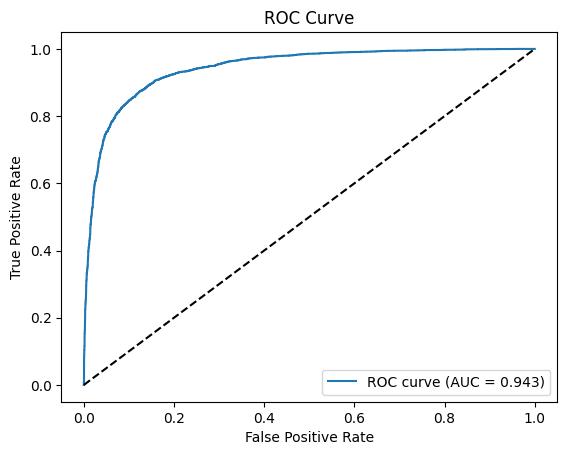

In [18]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
auc = roc_auc_score(y_test, y_pred_probs)
print("ROC-AUC:", auc)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)

# Compute AUC

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()